# Parte 5 - Asociación en BI

Implementación del algoritmo Apriori, Análisis de Canasta de Mercado, reglas de asociación y ventas cruzadas.

### Preparación del entorno

In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import os
import matplotlib.pyplot as plt 
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### Carga y visualización de los datos

In [2]:
DATA_DIR = '../data/processed'

# Ajuste de ruta si se corre como script
if not os.path.exists(DATA_DIR):
    DATA_DIR = 'data/processed'

df_ventas = pd.read_csv(f"{DATA_DIR}/Fact_Ventas.csv", sep=";", encoding="utf-8")
df_productos = pd.read_csv(f"{DATA_DIR}/Dim_Producto.csv", sep=";", encoding="utf-8")

# Unimos para obtener el nombre del producto
df = df_ventas.merge(df_productos[['id_producto', 'nombre']], on='id_producto', how='left')

# Normalizar texto por seguridad
df['nombre'] = df['nombre'].str.strip().str.title()
print("Datos cargados correctamente.")

Datos cargados correctamente.


In [3]:
df.head(5)

,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo,margen,nombre
0,45562,2025-06-29,575,46,5,31.0,1,91.66,27.50,64.16,59.04,5.12,Magnesio Quelado
1,34463,2024-12-29,3026,78,2,27.0,1,22.49,6.75,15.74,9.88,5.86,Salbutamol Inhalador
2,40559,2025-04-05,1496,381,8,NaN,1,58.19,0.00,58.19,33.74,24.45,Acondicionador Reparador
3,40576,2025-04-06,81,246,5,NaN,2,7.98,0.00,15.96,8.02,7.94,Azitromicina 500Mg
4,17499,2024-07-10,3289,418,2,NaN,2,75.67,0.00,151.34,79.20,72.14,Aceite Corporal Para Bebé


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59700 entries, 0 to 59699
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venta         59700 non-null  int64  
 1   fecha            59700 non-null  str    
 2   id_cliente       59700 non-null  int64  
 3   id_producto      59700 non-null  int64  
 4   id_tienda        59700 non-null  int64  
 5   id_promocion     23677 non-null  float64
 6   cantidad         59700 non-null  int64  
 7   precio_unitario  59700 non-null  float64
 8   descuento        59700 non-null  float64
 9   importe          59700 non-null  float64
 10  costo            59700 non-null  float64
 11  margen           59700 non-null  float64
 12  nombre           59700 non-null  str    
dtypes: float64(6), int64(5), str(2)
memory usage: 5.9 MB


In [5]:
df.describe()

,id_venta,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo,margen
count,59700.000000,59700.000000,59700.000000,59700.000000,23677.000000,59700.000000,59700.000000,59700.000000,59700.000000,59700.000000,59700.000000
mean,29997.460402,2490.465946,251.762764,8.022881,22.725345,1.377504,58.099548,5.501187,74.599022,43.895751,30.703271
std,17324.465298,1450.074701,146.602039,4.307889,10.681051,0.626329,64.892526,15.686326,99.102435,58.282252,44.251456
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.340000,0.000000,0.740000,1.010000,-44.790000
25%,14989.750000,1226.000000,122.000000,4.000000,14.000000,1.000000,17.790000,0.000000,19.330000,11.190000,7.050000
50%,29992.500000,2516.500000,254.000000,8.000000,24.000000,1.000000,35.670000,0.000000,40.540000,24.160000,16.020000
75%,45005.250000,3747.000000,379.000000,12.000000,32.000000,2.000000,72.930000,3.950000,87.122500,53.170000,34.690000
max,60000.000000,5000.000000,500.000000,15.000000,40.000000,3.000000,358.460000,317.880000,1073.370000,558.210000,594.390000


### Construir el formato transaccional

In [6]:
# Como id_venta resultó ser un identificador de línea de detalle en lugar de la boleta completa,
# reconstruimos el ticket agrupando por cliente, fecha y tienda.
# Removemos duplicados dentro del mismo ticket para no contar el mismo producto dos veces.
transacciones = df.drop_duplicates(subset=['id_cliente', 'fecha', 'id_tienda', 'nombre'])
transacciones_lista = transacciones.groupby(["id_cliente", "fecha", "id_tienda"])["nombre"].apply(list).tolist()

print(f"Total de transacciones (boletas): {len(transacciones_lista)}")
print("Ejemplo de canastas:", transacciones_lista[:3])

Total de transacciones (boletas): 32383
Ejemplo de canastas: [['Loción Corporal Hidratante'], ['Tensiómetro Digital De Brazo'], ['Zinc 50Mg', 'Jabón En Barra Glicerina']]


### Generar la matriz binaria (one-hot)

In [7]:
# Codificación One-Hot
te = TransactionEncoder()
matriz = te.fit_transform(transacciones_lista)
basket = pd.DataFrame(matriz, columns=te.columns_)

print(f"Dimensiones de la matriz de canastas: {basket.shape}")

Dimensiones de la matriz de canastas: (32383, 81)


### Obtener los itemsets frecuentes con Apriori

Se utiliza un `min_support = 0.001 (0.1%)` porque al usar nombres de productos específicos (son ~500) las frecuencias individuales y combinadas caen drásticamente en comparación con categorías.

In [8]:
soporte_minimo = 0.001 

frecuentes = apriori(basket, min_support=soporte_minimo, use_colnames=True)
frecuentes['longitud'] = frecuentes['itemsets'].apply(len) 
  
print("Itemsets frecuentes encontrados:", len(frecuentes)) 
frecuentes.sort_values('support', ascending=False).head(10) 

Itemsets frecuentes encontrados: 372


,support,itemsets,longitud
7,0.083346,frozenset({Azitromicina 500Mg}),1
61,0.077170,frozenset({Pulsioxímetro Digital}),1
43,0.073156,frozenset({Magnesio Quelado}),1
70,0.056573,frozenset({Tensiómetro Digital De Brazo}),1
36,0.049192,frozenset({Jabón En Barra Glicerina}),1
2,0.048112,frozenset({Alcohol En Gel 500Ml}),1
0,0.047772,frozenset({Aceite Corporal Para Bebé}),1
24,0.046660,frozenset({Esparadrapo Hipoalergénico}),1
71,0.046629,frozenset({Termómetro Digital}),1
3,0.042121,frozenset({Alcohol Medicinal 70° 250Ml}),1


### Generar las reglas de asociación

In [9]:
# Derivar reglas
# min_threshold=1.0 para lift asegura que la asociación sea positiva (ocurren juntos más de lo esperado)
reglas = association_rules(frecuentes, metric="lift", min_threshold=1.0)

# Ordenar por Lift (fuerza) y Confianza
reglas = reglas.sort_values(by=["lift", "confidence"], ascending=[False, False])

# Mostramos las 10 mejores reglas
print("\nTOP 10 Reglas de Asociación")
print("Reglas generadas:", len(reglas)) 

# Convertir frozensets a strings legibles
reglas_print = reglas.copy()
reglas_print["antecedents"] = reglas_print["antecedents"].apply(lambda x: ', '.join(list(x)))
reglas_print["consequents"] = reglas_print["consequents"].apply(lambda x: ', '.join(list(x)))
reglas_print[["antecedents", "consequents", "support", "confidence", "lift"]].head(10) 


TOP 10 Reglas de Asociación
Reglas generadas: 302


,antecedents,consequents,support,confidence,lift
140,Shampoo Anticaspa,Desodorante Roll-On,0.001173,0.072937,2.030875
141,Desodorante Roll-On,Shampoo Anticaspa,0.001173,0.032674,2.030875
292,Toallitas Húmedas X80,Talco Corporal,0.001760,0.065068,1.980369
293,Talco Corporal,Toallitas Húmedas X80,0.001760,0.053571,1.980369
98,Paracetamol 500Mg,Colágeno Hidrolizado,0.001235,0.068027,1.956417
99,Colágeno Hidrolizado,Paracetamol 500Mg,0.001235,0.035524,1.956417
105,Desodorante Roll-On,Contorno De Ojos,0.001390,0.038693,1.945647
104,Contorno De Ojos,Desodorante Roll-On,0.001390,0.069876,1.945647
113,Crema Antipañalitis,Enjuague Bucal Menta,0.001606,0.042588,1.899626
112,Enjuague Bucal Menta,Crema Antipañalitis,0.001606,0.071625,1.899626


### Visualizar las reglas 

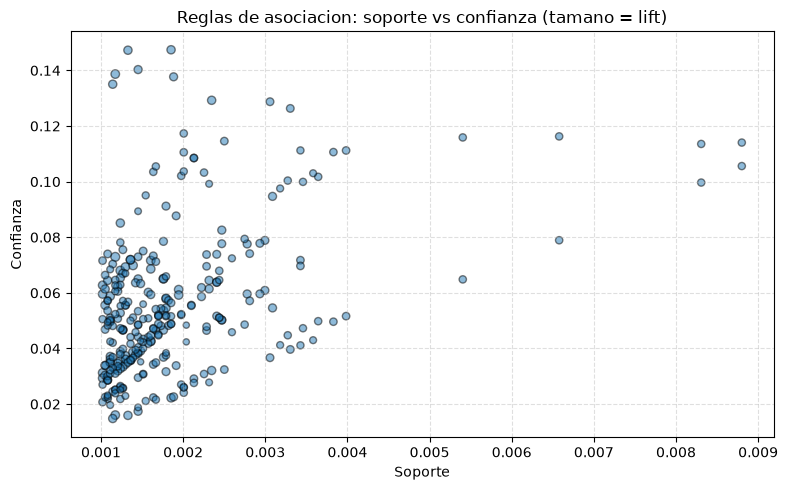

In [10]:
plt.figure(figsize=(8, 5)) 
plt.scatter(reglas['support'], reglas['confidence'], 
s=reglas['lift'] * 20, alpha=0.5, edgecolors='black') 
plt.xlabel('Soporte') 
plt.ylabel('Confianza') 
plt.title('Reglas de asociacion: soporte vs confianza (tamano = lift)') 
plt.grid(True, linestyle='--', alpha=0.4) 
plt.tight_layout() 
plt.show() 

### Acciones y estrategias (Venta Cruzada)

Con las reglas de mayor Lift obtenidas, sugerimos las siguientes estrategias para Power BI:

1. **Ubicación de productos:** Colocar físicamente o en el catálogo web los productos del *Consecuente* cerca de los del *Antecedente*.
2. **Promociones cruzadas:** Si un cliente añade el *Antecedente* a su carrito, ofrecerle un pequeño descuento en el *Consecuente*.
3. **Paquetes (Bundles):** Crear kits de salud (ej. Antigripal + Vitamina C) con un precio especial combinando las reglas más fuertes.

### Exportación de datos

In [11]:
# Limpieza
reglas["antecedents"] = reglas["antecedents"].apply(lambda x: ', '.join(list(x)))
reglas["consequents"] = reglas["consequents"].apply(lambda x: ', '.join(list(x)))

# Seleccionamos las columnas útiles para el dashboard
columnas_exportacion = ["antecedents", "consequents", "antecedent support", "consequent support", "support", "confidence", "lift"]
df_export = reglas[columnas_exportacion].copy()

# Renombrar columnas para claridad en Power BI
df_export.columns = ["Antecedente", "Consecuente", "Soporte Antecedente", "Soporte Consecuente", "Soporte Regla", "Confianza", "Lift"]

ruta_salida = f"{DATA_DIR}/reglas_asociacion.csv"
df_export.to_csv(ruta_salida, sep=";", index=False, encoding="utf-8")
print("Exportación completada correctamente.")

Exportación completada correctamente.
